In [33]:
!pip install pandas
import pandas as pd
import numpy as np
df = pd.read_csv('ESG Data Analytics Task.csv')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df.head()

,Facility ID,Facility Name,Reporting Period,Scope,GHG Type,Emissions (tons)
0,F088,JSW Energy,2022 Q1,Scope 3,CH₄,2435.597408
1,F021,L&T,2022 Q2,Scope 1,CO₂,835.450000
2,F107,Reliance Industries,2022 Q2,Scope 1,CO₂,3430.450000
3,F106,Tata Steel,2022 Q1,Scope 1,CO₂,4214.240000
4,F090,Reliance Industries,2022 Q2,Scope 3,CH₄,605.593547


In [3]:
df.isnull().sum()

Facility ID         0
Facility Name       0
Reporting Period    0
Scope               0
GHG Type            0
Emissions (tons)    0
dtype: int64

In [7]:
# df.duplicated(subset=['Facility ID ']).sum()
df['Facility ID'].nunique()
 

200

In [8]:
# Duplicate / Conflicting Facility IDs

facility_id_col = "Facility ID"
facility_col = "Facility Name"

mapping_counts = (
    df.groupby(facility_id_col)[facility_col]
    .nunique()
    .reset_index(name="unique_facilities")
)

conflicting_ids = mapping_counts[
    mapping_counts["unique_facilities"] > 1
]

print(conflicting_ids)

Empty DataFrame
Columns: [Facility ID, unique_facilities]
Index: []


In [9]:
facility_conflicts = df[
    df[facility_id_col].isin(conflicting_ids[facility_id_col])
][[facility_id_col, facility_col]].drop_duplicates()

print(facility_conflicts)

Empty DataFrame
Columns: [Facility ID, Facility Name]
Index: []


In [10]:
df[facility_col] = (
    df[facility_col]
    .str.strip()
    .str.title()
)

print(df[[facility_id_col, facility_col]].head())

  Facility ID        Facility Name
0        F088           Jsw Energy
1        F021                  L&T
2        F107  Reliance Industries
3        F106           Tata Steel
4        F090  Reliance Industries


In [12]:
# decimal precision

emissions_col = "Emissions (tons)"

def decimal_places(x):
    s = str(x)

    if "." in s:
        return len(s.split(".")[1])

    return 0

df["decimal_places"] = df[emissions_col].apply(decimal_places)

precision_issues = df[df["decimal_places"] > 4]

print(precision_issues[[emissions_col, "decimal_places"]])

      Emissions (tons)  decimal_places
0          2435.597408              11
4           605.593547              12
6          4455.934090              10
7           660.197536              12
8          1883.304313              11
...                ...             ...
1987       4839.808496               9
1989       3907.241328              11
1990       2483.820612              11
1992       2912.662667              11
1994       5275.242254              11

[551 rows x 2 columns]


In [13]:
df[emissions_col] = pd.to_numeric(
    df[emissions_col],
    errors="coerce"
).round(4)

print(df[emissions_col].head())

0    2435.5974
1     835.4500
2    3430.4500
3    4214.2400
4     605.5935
Name: Emissions (tons), dtype: float64


In [16]:
# missing values

df = df.fillna("Unknown")
df = df.dropna()

In [17]:
# Data Type Validation
invalid_numeric = df[
    pd.to_numeric(
        df[emissions_col],
        errors="coerce"
    ).isnull()
]

print(invalid_numeric)


Empty DataFrame
Columns: [Facility ID, Facility Name, Reporting Period, Scope, GHG Type, Emissions (tons), decimal_places]
Index: []


In [18]:
df[emissions_col] = pd.to_numeric(
    df[emissions_col],
    errors="coerce"
)

In [19]:
scope_col = "Scope"

invalid_scope = df[
    ~df[scope_col].astype(str).isin(["1", "2", "3"])
]

print(invalid_scope)

     Facility ID        Facility Name Reporting Period    Scope GHG Type  \
0           F088           Jsw Energy          2022 Q1  Scope 3      CH₄   
1           F021                  L&T          2022 Q2  Scope 1      CO₂   
2           F107  Reliance Industries          2022 Q2  Scope 1      CO₂   
3           F106           Tata Steel          2022 Q1  Scope 1      CO₂   
4           F090  Reliance Industries          2022 Q2  Scope 3      CH₄   
...          ...                  ...              ...      ...      ...   
1995        F128  Reliance Industries          2022 Q1  Scope 1      CO₂   
1996        F064                  L&T          2023 Q1  Scope 3      CO₂   
1997        F185           Jsw Energy          2023 Q1  Scope 2      CO₂   
1998        F007          Adani Green          2023 Q2  Scope 3      CH₄   
1999        F018          Adani Green          2023 Q1  Scope 2      N₂O   

      Emissions (tons)  decimal_places  
0            2435.5974              11  
1    

In [20]:
df = df[
    df[scope_col].astype(str).isin(["1", "2", "3"])
]

In [22]:
# Reporting Period Validation

period_col = "Reporting Period"

invalid_period = df[
    ~df[period_col]
    .astype(str)
    .str.match(r"^\d{4}\sQ[1-4]$")
]

print(invalid_period[[period_col]])

Empty DataFrame
Columns: [Reporting Period]
Index: []


In [23]:
df[period_col] = df[period_col].str.strip()

In [24]:
# outlier detection

mean_val = df[emissions_col].mean()
std_val = df[emissions_col].std()

threshold = mean_val + 3 * std_val

outliers = df[
    df[emissions_col] > threshold
]

print(outliers)

Empty DataFrame
Columns: [Facility ID, Facility Name, Reporting Period, Scope, GHG Type, Emissions (tons), decimal_places]
Index: []


In [25]:
df = df[
    df[emissions_col] <= threshold
]

In [26]:
df["Outlier_Flag"] = np.where(
    df[emissions_col] > threshold,
    "Yes",
    "No"
)

print(df[["Outlier_Flag"]].head())

NameError: name 'np' is not defined

In [27]:
ghg_col = "GHG Type"

valid_ghgs = ["CO2", "CH4", "N2O", "CO₂", "CH₄", "N₂O"]

invalid_ghg = df[
    ~df[ghg_col].isin(valid_ghgs)
]

print(invalid_ghg)

Empty DataFrame
Columns: [Facility ID, Facility Name, Reporting Period, Scope, GHG Type, Emissions (tons), decimal_places]
Index: []


In [28]:
df[ghg_col] = (
    df[ghg_col]
    .replace("CO₂", "CO2")
    .replace("CH₄", "CH4")
    .replace("N₂O", "N2O")
)

In [30]:
all_periods = sorted(df[period_col].unique())

print(all_periods)
df = df.sort_values(by=period_col)


[]


In [31]:
df[facility_col] = (
    df[facility_col]
    .str.strip()
    .str.title()
)

print(df[facility_col].unique())

[]


In [34]:
# Clean and validate data with concise checks
clean_df = df.copy()

# Standardize text fields
clean_df["Facility Name"] = clean_df["Facility Name"].astype(str).str.strip().str.title()
clean_df["Scope"] = clean_df["Scope"].astype(str).str.strip()
clean_df["GHG Type"] = (
    clean_df["GHG Type"].astype(str).str.strip()
    .replace({"CO₂": "CO2", "CH₄": "CH4", "N₂O": "N2O"})
)
clean_df["Reporting Period"] = clean_df["Reporting Period"].astype(str).str.strip()

# Numeric emissions with consistent precision
clean_df["Emissions (tons)"] = pd.to_numeric(
    clean_df["Emissions (tons)"],
    errors="coerce"
 ).round(4)

# Validate required fields and drop rows with missing critical values
required_cols = [
    "Facility ID",
    "Facility Name",
    "Reporting Period",
    "Scope",
    "GHG Type",
    "Emissions (tons)",
 ]
missing_required = clean_df[required_cols].isna().sum()
clean_df = clean_df.dropna(subset=required_cols)

# Normalize scope values to 'Scope 1/2/3'
scope_map = {"1": "Scope 1", "2": "Scope 2", "3": "Scope 3"}
clean_df["Scope"] = clean_df["Scope"].replace(scope_map)
valid_scopes = {"Scope 1", "Scope 2", "Scope 3"}
invalid_scope = clean_df[~clean_df["Scope"].isin(valid_scopes)]
clean_df = clean_df[clean_df["Scope"].isin(valid_scopes)]

# Validate reporting period format YYYY Q#
period_ok = clean_df["Reporting Period"].str.match(r"^\d{4}\sQ[1-4]$")
invalid_period = clean_df[~period_ok]
clean_df = clean_df[period_ok]

# Check conflicting facility ID to name mapping
id_name_counts = (
    clean_df.groupby("Facility ID")["Facility Name"]
    .nunique()
    .reset_index(name="unique_facilities")
 )
conflicting_ids = id_name_counts[id_name_counts["unique_facilities"] > 1]

# Detect duplicates and outliers (flag only)
duplicate_rows = clean_df.duplicated().sum()
mean_val = clean_df["Emissions (tons)"].mean()
std_val = clean_df["Emissions (tons)"].std()
threshold = mean_val + 3 * std_val
clean_df["Outlier_Flag"] = np.where(
    clean_df["Emissions (tons)"] > threshold,
    "Yes",
    "No"
 )

# Summary of unclear data
print("Missing required values (before drop):")
print(missing_required)
print("\nInvalid scope rows:", len(invalid_scope))
print("Invalid reporting period rows:", len(invalid_period))
print("Duplicate rows:", duplicate_rows)
print("Conflicting Facility IDs:")
print(conflicting_ids)
print("\nOutliers flagged:", (clean_df["Outlier_Flag"] == "Yes").sum())

# Preview cleaned data
clean_df.head()

Missing required values (before drop):
Facility ID         0
Facility Name       0
Reporting Period    0
Scope               0
GHG Type            0
Emissions (tons)    0
dtype: int64

Invalid scope rows: 0
Invalid reporting period rows: 0
Duplicate rows: 0
Conflicting Facility IDs:
Empty DataFrame
Columns: [Facility ID, unique_facilities]
Index: []

Outliers flagged: 0


,Facility ID,Facility Name,Reporting Period,Scope,GHG Type,Emissions (tons),Outlier_Flag
0,F088,Jsw Energy,2022 Q1,Scope 3,CH4,2435.5974,No
1,F021,L&T,2022 Q2,Scope 1,CO2,835.4500,No
2,F107,Reliance Industries,2022 Q2,Scope 1,CO2,3430.4500,No
3,F106,Tata Steel,2022 Q1,Scope 1,CO2,4214.2400,No
4,F090,Reliance Industries,2022 Q2,Scope 3,CH4,605.5935,No


In [35]:
# Save cleaned data
output_path = "ESG Data Analytics Task.cleaned.csv"
clean_df.to_csv(output_path, index=False)
print("Saved:", output_path)

Saved: ESG Data Analytics Task.cleaned.csv


Pivot A: Total Emissions by Facility


,Emissions (tons)
Facility Name,
Adani Green,1.361113e+06
Tata Steel,1.128000e+06
Reliance Industries,9.646896e+05
Jsw Energy,9.465145e+05
L&T,8.160746e+05


Pivot B: Emissions by Scope


,Emissions (tons)
Scope,
Scope 3,1.766860e+06
Scope 1,1.763844e+06
Scope 2,1.685688e+06


Pivot C: Quarterly Trend Analysis


,Reporting Period,Emissions (tons)
0,2022 Q1,1.256203e+06
1,2022 Q2,1.357086e+06
2,2023 Q1,1.346029e+06
3,2023 Q2,1.257074e+06


Pivot D: Facility + Quarter Combined


,Facility Name,Reporting Period,Emissions (tons)
0,Adani Green,2022 Q1,340708.9153
1,Adani Green,2022 Q2,326256.5978
2,Adani Green,2023 Q1,360843.2143
3,Adani Green,2023 Q2,333304.5884
4,Jsw Energy,2022 Q1,203900.7682
5,Jsw Energy,2022 Q2,284347.8093
6,Jsw Energy,2023 Q1,217291.7714
7,Jsw Energy,2023 Q2,240974.1356
8,L&T,2022 Q1,188012.6090
9,L&T,2022 Q2,211151.0942


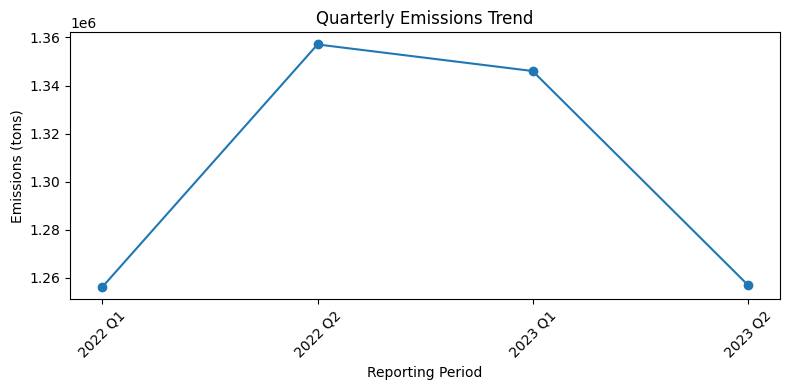

<Figure size 800x400 with 0 Axes>

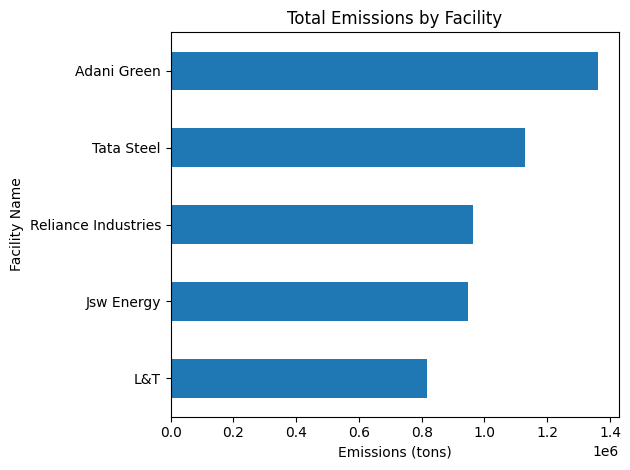

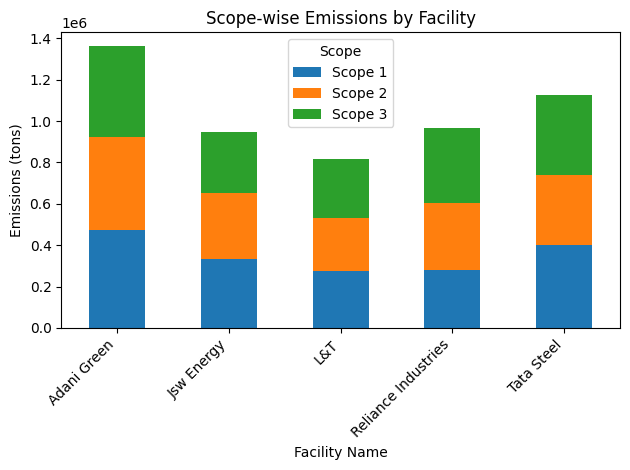

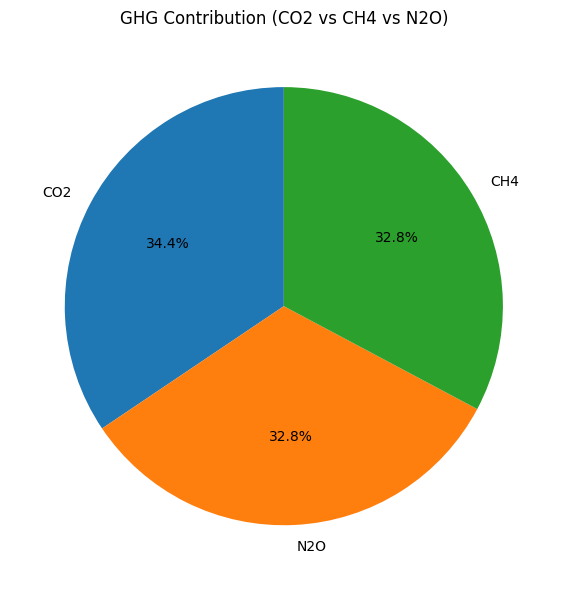

In [36]:
import matplotlib.pyplot as plt

# Pivot A: Total Emissions by Facility
pivot_facility = (
    clean_df.pivot_table(
        index="Facility Name",
        values="Emissions (tons)",
        aggfunc="sum"
    ).sort_values(by="Emissions (tons)", ascending=False)
)
print("Pivot A: Total Emissions by Facility")
display(pivot_facility)

# Pivot B: Emissions by Scope
pivot_scope = clean_df.pivot_table(
    index="Scope",
    values="Emissions (tons)",
    aggfunc="sum"
).sort_values(by="Emissions (tons)", ascending=False)
print("Pivot B: Emissions by Scope")
display(pivot_scope)

# Pivot C: Quarterly Trend Analysis
period_parts = clean_df["Reporting Period"].str.extract(r"(?P<Year>\d{4})\sQ(?P<Quarter>[1-4])")
clean_df["Year"] = period_parts["Year"].astype(int)
clean_df["Quarter"] = period_parts["Quarter"].astype(int)
clean_df["PeriodSort"] = clean_df["Year"] * 10 + clean_df["Quarter"]

pivot_quarter = clean_df.pivot_table(
    index="Reporting Period",
    values="Emissions (tons)",
    aggfunc="sum"
).reset_index()
pivot_quarter["PeriodSort"] = (
    pivot_quarter["Reporting Period"].str.extract(r"(?P<Year>\d{4})\sQ(?P<Quarter>[1-4])")
    .assign(Year=lambda x: x["Year"].astype(int), Quarter=lambda x: x["Quarter"].astype(int))
    .eval("Year * 10 + Quarter")
)
pivot_quarter = pivot_quarter.sort_values(by="PeriodSort")
print("Pivot C: Quarterly Trend Analysis")
display(pivot_quarter[["Reporting Period", "Emissions (tons)"]])

# Pivot D: Facility + Quarter Combined
pivot_facility_quarter = clean_df.pivot_table(
    index=["Facility Name", "Reporting Period"],
    values="Emissions (tons)",
    aggfunc="sum"
).reset_index()
pivot_facility_quarter["PeriodSort"] = (
    pivot_facility_quarter["Reporting Period"].str.extract(r"(?P<Year>\d{4})\sQ(?P<Quarter>[1-4])")
    .assign(Year=lambda x: x["Year"].astype(int), Quarter=lambda x: x["Quarter"].astype(int))
    .eval("Year * 10 + Quarter")
)
pivot_facility_quarter = pivot_facility_quarter.sort_values(
    by=["Facility Name", "PeriodSort"]
 )
print("Pivot D: Facility + Quarter Combined")
display(pivot_facility_quarter[["Facility Name", "Reporting Period", "Emissions (tons)"]])

# Charts
plt.figure(figsize=(8, 4))
plt.plot(
    pivot_quarter["Reporting Period"],
    pivot_quarter["Emissions (tons)"],
    marker="o"
 )
plt.title("Quarterly Emissions Trend")
plt.xlabel("Reporting Period")
plt.ylabel("Emissions (tons)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
pivot_facility.sort_values(by="Emissions (tons)", ascending=True).plot(
    kind="barh",
    legend=False
)
plt.title("Total Emissions by Facility")
plt.xlabel("Emissions (tons)")
plt.ylabel("Facility Name")
plt.tight_layout()
plt.show()

scope_by_facility = clean_df.pivot_table(
    index="Facility Name",
    columns="Scope",
    values="Emissions (tons)",
    aggfunc="sum",
    fill_value=0
 )
scope_by_facility.plot(
    kind="bar",
    stacked=True,
)
plt.title("Scope-wise Emissions by Facility")
plt.xlabel("Facility Name")
plt.ylabel("Emissions (tons)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

ghg_share = clean_df.pivot_table(
    index="GHG Type",
    values="Emissions (tons)",
    aggfunc="sum"
).sort_values(by="Emissions (tons)", ascending=False)
plt.figure(figsize=(6, 6))
plt.pie(
    ghg_share["Emissions (tons)"],
    labels=ghg_share.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("GHG Contribution (CO2 vs CH4 vs N2O)")
plt.tight_layout()
plt.show()

# Dashboard

Interactive dashboard with KPI cards, charts, and filters for facility, scope, and reporting period.

In [37]:
import warnings
from IPython.display import display, HTML, clear_output

warnings.filterwarnings("ignore")

try:
    import ipywidgets as widgets
except Exception as exc:
    raise ImportError(
        "ipywidgets is required for the dashboard. Run: pip install ipywidgets"
    ) from exc

# Filter controls
facility_options = ["All"] + sorted(clean_df["Facility Name"].unique().tolist())
scope_options = ["All"] + sorted(clean_df["Scope"].unique().tolist())
period_options = ["All"] + sorted(clean_df["Reporting Period"].unique().tolist())

facility_dd = widgets.Dropdown(options=facility_options, value="All", description="Facility:")
scope_dd = widgets.Dropdown(options=scope_options, value="All", description="Scope:")
period_dd = widgets.Dropdown(options=period_options, value="All", description="Period:")

controls = widgets.HBox([facility_dd, scope_dd, period_dd])
output = widgets.Output()

def apply_filters(data):
    filtered = data.copy()
    if facility_dd.value != "All":
        filtered = filtered[filtered["Facility Name"] == facility_dd.value]
    if scope_dd.value != "All":
        filtered = filtered[filtered["Scope"] == scope_dd.value]
    if period_dd.value != "All":
        filtered = filtered[filtered["Reporting Period"] == period_dd.value]
    return filtered

def render_dashboard():
    with output:
        clear_output()
        data = apply_filters(clean_df)

        if data.empty:
            display(HTML("<b>No data for selected filters.</b>"))
            return

        total_emissions = data["Emissions (tons)"].sum()
        facility_totals = data.groupby("Facility Name")["Emissions (tons)"].sum()
        top_facility = facility_totals.idxmax()
        top_facility_value = facility_totals.max()

        quarter_totals = (
            data.groupby("Reporting Period")["Emissions (tons)"]
            .sum()
        )
        avg_quarter_emissions = quarter_totals.mean()

        scope_totals = data.groupby("Scope")["Emissions (tons)"].sum()
        top_scope = scope_totals.idxmax()
        top_scope_value = scope_totals.max()

        kpi_html = f"""
        <div style='display:flex; gap:12px; flex-wrap:wrap;'>
          <div style='border:1px solid #ddd; border-radius:6px; padding:10px; min-width:200px;'>
            <div style='font-size:12px; color:#555;'>Total Emissions</div>
            <div style='font-size:20px; font-weight:bold;'>{total_emissions:,.0f}</div>
          </div>
          <div style='border:1px solid #ddd; border-radius:6px; padding:10px; min-width:200px;'>
            <div style='font-size:12px; color:#555;'>Highest Emitting Facility</div>
            <div style='font-size:16px; font-weight:bold;'>{top_facility}</div>
            <div style='font-size:12px; color:#555;'>{top_facility_value:,.0f}</div>
          </div>
          <div style='border:1px solid #ddd; border-radius:6px; padding:10px; min-width:200px;'>
            <div style='font-size:12px; color:#555;'>Average Quarterly Emissions</div>
            <div style='font-size:20px; font-weight:bold;'>{avg_quarter_emissions:,.0f}</div>
          </div>
          <div style='border:1px solid #ddd; border-radius:6px; padding:10px; min-width:200px;'>
            <div style='font-size:12px; color:#555;'>Scope with Highest Emissions</div>
            <div style='font-size:16px; font-weight:bold;'>{top_scope}</div>
            <div style='font-size:12px; color:#555;'>{top_scope_value:,.0f}</div>
          </div>
        </div>
        """
        display(HTML(kpi_html))

        # Quarterly trend
        quarter_df = quarter_totals.reset_index()
        quarter_df["PeriodSort"] = (
            quarter_df["Reporting Period"].str.extract(r"(?P<Year>\d{4})\sQ(?P<Quarter>[1-4])")
            .assign(Year=lambda x: x["Year"].astype(int), Quarter=lambda x: x["Quarter"].astype(int))
            .eval("Year * 10 + Quarter")
        )
        quarter_df = quarter_df.sort_values(by="PeriodSort")

        plt.figure(figsize=(7, 3.5))
        plt.plot(
            quarter_df["Reporting Period"],
            quarter_df["Emissions (tons)"],
            marker="o"
        )
        plt.title("Quarterly Emissions Trend")
        plt.xlabel("Reporting Period")
        plt.ylabel("Emissions (tons)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Facility comparison (top 10)
        top_facilities = facility_totals.sort_values(ascending=False).head(10)
        plt.figure(figsize=(7, 4))
        top_facilities.sort_values().plot(kind="barh", color="#4C78A8")
        plt.title("Facility Comparison (Top 10)")
        plt.xlabel("Emissions (tons)")
        plt.ylabel("Facility Name")
        plt.tight_layout()
        plt.show()

        # Scope analysis
        plt.figure(figsize=(6, 3.5))
        scope_totals.sort_values(ascending=False).plot(kind="bar", color="#F58518")
        plt.title("Scope Analysis")
        plt.xlabel("Scope")
        plt.ylabel("Emissions (tons)")
        plt.tight_layout()
        plt.show()

def on_change(_):
    render_dashboard()

facility_dd.observe(on_change, names="value")
scope_dd.observe(on_change, names="value")
period_dd.observe(on_change, names="value")

display(controls)
display(output)
render_dashboard()

Output()

# Strategic Recommendations (Net Zero to 2050)

## Operational Improvements
- Upgrade to energy-efficient machinery and motors.
- Optimize processes with real-time monitoring and automation.
- Deploy waste heat recovery in high-temperature operations.

## Renewable Energy
- Integrate on-site solar where feasible.
- Procure wind power through long-term PPAs.
- Source green electricity certificates for remaining grid use.

## Scope 3 Reduction
- Shift to sustainable suppliers with ESG targets.
- Optimize logistics with low-carbon transport and routing.
- Require supplier ESG audits and performance reporting.

## LCA Integration
- Evaluate full product lifecycle emissions (cradle-to-grave).
- Reduce embedded carbon via low-carbon materials.
- Increase recycled and sustainably sourced inputs.